<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Decision Tree on Breast Cancer Dataset</b>
</h1>

<div style="font-family:'Times New Roman';">

<b>Goal:</b>

<ol>
<li>Train a Decision Tree on a real dataset.</li>
<li>Evaluate how well the model performs.</li>
<li>Visualize the learned tree structure.</li>
<li>Understand which features were most important.</li>
</ol>

In this notebook, I'll use the Breast Cancer dataset to see how a Decision Tree learns patterns and makes predictions using a series of rules.

</div>

In [1]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# load dataset

data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
# basic information

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nClasses :", data.target_names)

Features Shape : (569, 30)
Target Shape : (569,)

Classes : ['malignant' 'benign']


In [4]:
# convert to dataframe

df = pd.DataFrame(X, columns=data.feature_names)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# class distribution

pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Dataset Overview</b>
</h2>

<div style="font-family:'Times New Roman';">

This is a binary classification dataset.

<ul>
<li><b>0:</b> Malignant</li>
<li><b>1:</b> Benign</li>
</ul>

The goal is to predict whether a tumor is malignant or benign based on different medical measurements.

</div>

In [7]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why No Scaling?</b>
</h2>

<div style="font-family:'Times New Roman';">

Unlike KNN, Decision Trees do not use distance calculations.

They split the data based on feature values, so scaling is usually not needed.

</div>

In [8]:
# train model

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
# predictions

y_pred = tree.predict(X_test)

In [10]:
# accuracy

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", round(acc,4))

Accuracy : 0.9474


In [11]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  3]
 [ 3 68]]


In [12]:
# classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Model Performance</b>
</h2>

<div style="font-family:'Times New Roman';">

The Decision Tree was able to classify most samples correctly.

A confusion matrix helps us see where the model made mistakes, while Precision, Recall and F1 Score provide a more detailed evaluation.

</div>

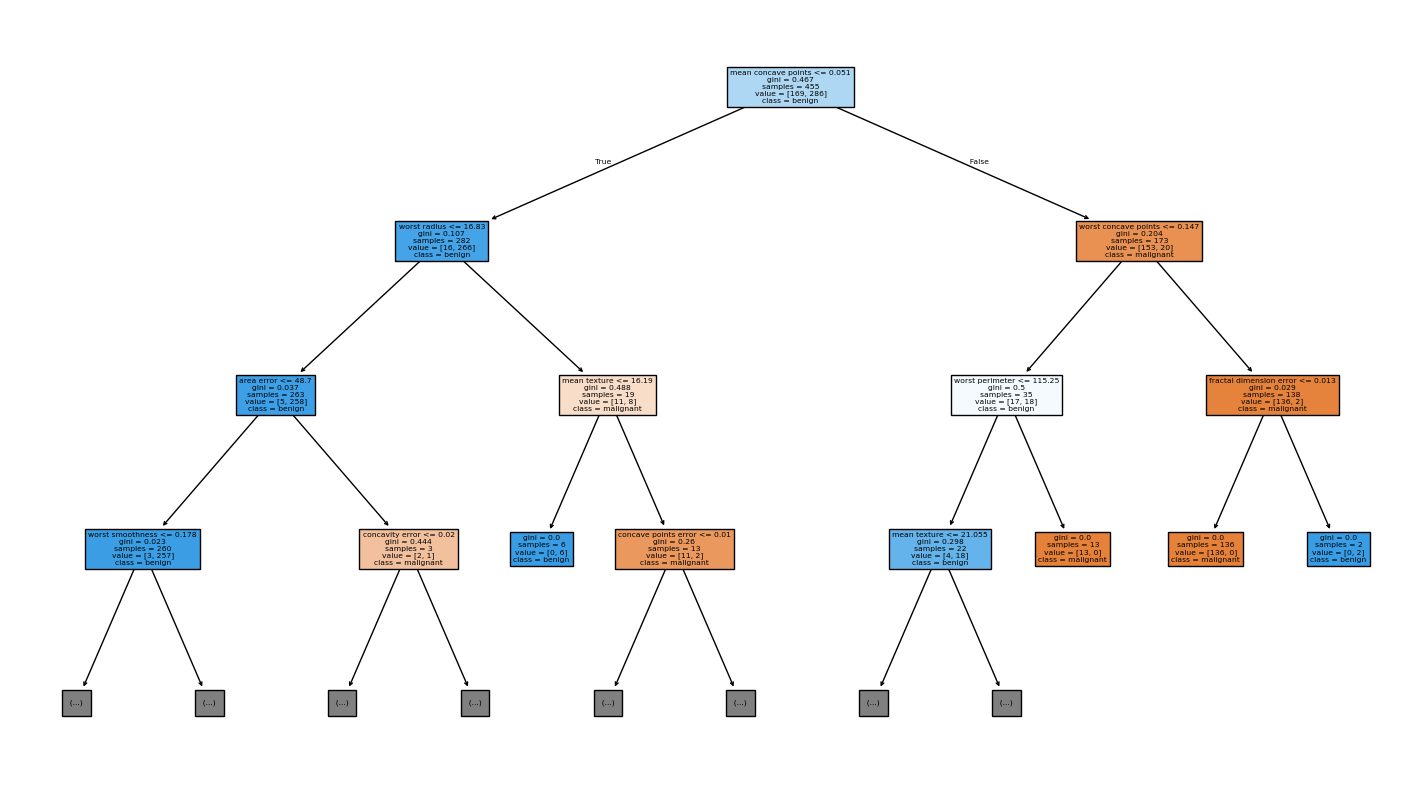

In [13]:
# visualize tree

plt.figure(figsize=(18,10))

plot_tree(
    tree,
    filled=True,
    max_depth=3,
    feature_names=data.feature_names,
    class_names=data.target_names
)

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Tree Visualization</b>
</h2>

<div style="font-family:'Times New Roman';">

Each node contains a condition.

The tree keeps splitting the data until it reaches a decision.

For readability only the first few levels of the tree are shown.

</div>

In [14]:
# feature importance

importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
7,mean concave points,0.691420
27,worst concave points,0.065651
1,mean texture,0.058478
20,worst radius,0.052299
22,worst perimeter,0.051494
19,fractal dimension error,0.018554
21,worst texture,0.017445
17,concave points error,0.015931
13,area error,0.011983
24,worst smoothness,0.009233


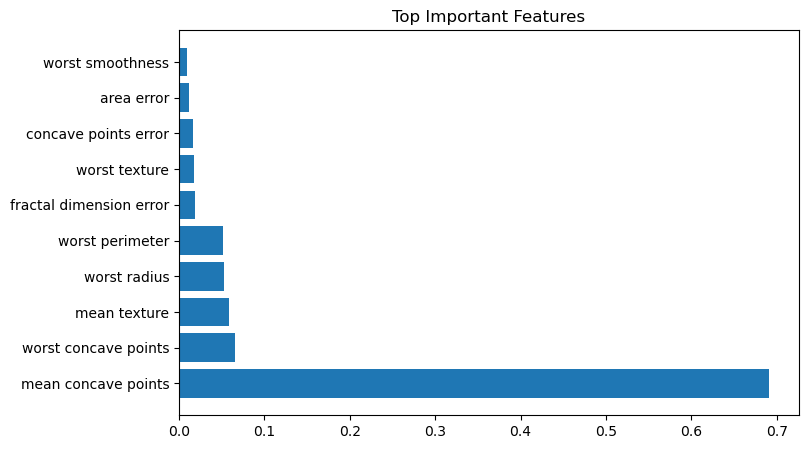

In [15]:
# top features

top_features = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Important Features")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Feature Importance</b>
</h2>

<div style="font-family:'Times New Roman';">

Decision Trees can tell us which features were most useful while making decisions.

Features with higher importance contributed more to the final predictions.

</div>

In [16]:
# training accuracy

train_acc = tree.score(X_train, y_train)

print("Train Accuracy :", round(train_acc,4))
print("Test Accuracy  :", round(acc,4))

Train Accuracy : 1.0
Test Accuracy  : 0.9474


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Overfitting Check</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li><b>Train Accuracy:</b> 100%</li>
<li><b>Test Accuracy:</b> 94.74%</li>
</ul>

The model performs perfectly on the training data, but the test accuracy is slightly lower.

This suggests that the tree may have learned some training-specific patterns instead of only learning general rules.

Decision Trees can easily overfit when they are allowed to grow without restrictions.

</div>

In [17]:
# limiting tree depth

tree_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_depth3.fit(X_train, y_train)

train_acc = tree_depth3.score(X_train, y_train)
test_acc = tree_depth3.score(X_test, y_test)

print("Train Accuracy :", round(train_acc,4))
print("Test Accuracy  :", round(test_acc,4))

Train Accuracy : 0.978
Test Accuracy  : 0.9474


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Effect of Limiting Tree Depth</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li><b>Before:</b> Train Accuracy = 100%</li>
<li><b>After:</b> Train Accuracy = 97.8%</li>
<li><b>Test Accuracy:</b> Remained at 94.74%</li>
</ul>

The tree became simpler after limiting its depth.

Even though the training accuracy decreased slightly, the test accuracy remained the same. This shows that the deeper tree was learning some patterns that were not really helping on unseen data.

A smaller tree is often easier to understand and generalizes better.

</div>